In [192]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

import re
import random

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

torch.set_num_threads(1)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [193]:
#extracting datasets
df_cnbc = pd.read_csv('Dataset/cnbc_headlines.csv')
df_guardian = pd.read_csv('Dataset/guardian_headlines.csv')
df_reuters = pd.read_csv('Dataset/reuters_headlines.csv')

#considering only headlines
headline_cnbc = list(df_cnbc['Headlines'])
headline_guardian = list(df_guardian['Headlines'])
headline_reuters = list(df_reuters['Headlines'])

#list of headlines
headline_list = headline_cnbc + headline_guardian + headline_reuters

print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#cleaning dataset

#filtering empty rows
headline_list = [h for h in headline_list if str(h) != 'nan']
print("No.of headlines in list: ",len(headline_list))
print(headline_list[:5])

#removing spaces in headline
def clean_headline(h):
    h = h.strip() #remove the trailing spaces from either end
    h = re.sub(r'\s+', ' ', h) #replace bigger spaces with a single space
    h = h.encode('ascii', 'ignore').decode()  # remove non-ASCII
    return h

headline_list = [clean_headline(h) for h in headline_list]

No.of headlines in list:  53650
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", nan, "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally']
No.of headlines in list:  53370
['Jim Cramer: A better way to invest in the Covid-19 vaccine gold rush', "Cramer's lightning round: I would own Teradyne", "Cramer's week ahead: Big week for earnings, even bigger week for vaccines", 'IQ Capital CEO Keith Bliss says tech and healthcare will rally', "Wall Street delivered the 'kind of pullback I've been waiting for,' Jim Cramer says"]


In [194]:
print(len(headline_list))

53370


In [195]:
#vocabulary set
unique_words = set()

for headline in headline_list:
    for letter in list(headline):
        unique_words.add(letter)
    
unique_words = ['<S>', '<E>'] + sorted(unique_words)
vocab_size = len(unique_words)
print("Vocabulary size: ",vocab_size)

#number to word matrix
num2letter_dict = {i:letter for i, letter in enumerate(unique_words)}

#word to number matrix
letter2num_dict = {letter:i for i, letter in enumerate(unique_words)}


Vocabulary size:  84


In [196]:
#building the dataset
block_size = 8

def build_dataset(headline_list):
    context_x = [] #list of all context windows
    targets_y = [] #list of all targets
    for chs in headline_list:
        context_window = [0]*block_size
        for ch in list(chs) + ['<E>']:
            idx = letter2num_dict[ch]
            context_x.append(context_window)
            targets_y.append(idx)
            context_window = context_window[1:] + [idx] #slide context window
        
    #convert the list of context windows and targets into tensors
    context_x = torch.tensor(context_x)
    targets_y = torch.tensor(targets_y)
    return context_x, targets_y

random.seed(42)
random.shuffle(headline_list)
n1 = int(0.8*len(headline_list)) #-> 80% of headline_list
n2 = int(0.9*len(headline_list)) #-> 90% of headline_list

#splitting into train, validation and test datasets
Xtr, Ytr = build_dataset(headline_list[:n1]) #-> 80%
Xval, Yval = build_dataset(headline_list[n1:n2]) #-> 10%
Xtest, Ytest = build_dataset(headline_list[n2:]) #->10%

In [197]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(' '.join(num2letter_dict[ix.item()] for ix in x), '==>', num2letter_dict[y.item()])

<S> <S> <S> <S> <S> <S> <S> <S> ==> T
<S> <S> <S> <S> <S> <S> <S> T ==> w
<S> <S> <S> <S> <S> <S> T w ==> o
<S> <S> <S> <S> <S> T w o ==>  
<S> <S> <S> <S> T w o   ==> H
<S> <S> <S> T w o   H ==> u
<S> <S> T w o   H u ==> a
<S> T w o   H u a ==> w
T w o   H u a w ==> e
w o   H u a w e ==> i
o   H u a w e i ==>  
  H u a w e i   ==> s
H u a w e i   s ==> t
u a w e i   s t ==> a
a w e i   s t a ==> f
w e i   s t a f ==> f
e i   s t a f f ==>  
i   s t a f f   ==> e
  s t a f f   e ==> x
s t a f f   e x ==> p


# Python Classes in this MLP — What each method does

## `__init__`
The constructor. Runs **once** when you create the object. Sets up all internal variables (weights, biases, parameters). Think of it as "building the layer before using it."
```python
layer = Linear(30, 200)  # __init__ runs here
```

## `__call__`
Runs when you "call" the object like a function. This is the **forward pass** — takes input `x`, does the computation, returns output.
```python
out = layer(x)  # __call__ runs here
```
Without `__call__`, you'd have to write `layer.forward(x)` every time. `__call__` lets you treat the layer like a function.

## `parameters()`
Returns a list of all tensors that need to be updated by gradient descent. The training loop calls this on every layer to collect all learnable weights in one place:
```python
parameters = []
for layer in layers:
    parameters += layer.parameters()
# now update all of them in one loop
```
Only learnable tensors go here — NOT running stats like `running_mean`/`running_var` in batchnorm, since those aren't updated by gradients.


In [198]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out))/fan_in**0.5 #KAIMING NORMALIZATION
        self.bias = torch.randn(fan_out) if bias else None
    
    def __call__(self, x):
        self.out = x @ self.weight #linear equation
        if self.bias is not None:
            self.out += self.bias #check for bias and add
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias]) #array of weights

In [199]:
class BatchNorm1d:
    def __init__(self, dim, epsilon=1e-5, momentum=0.1):
        self.epsilon = epsilon #(epsilon) prevents zero division in norm
        self.momentum = momentum #how fast running stats updates (running_mean and batchnorm mean) during inference
        self.training = True #flag b/w training and inference states
        #--parameters (trained in backprop)--
        self.gamma = torch.ones(dim) #bngain
        self.beta = torch.zeros(dim) #bnbias
        #--buffers (trained with a running "momentum" update)--
        self.running_mean = torch.zeros(dim) #tracks mean across batches for inference
        self.running_var = torch.ones(dim) #tracks variance across batches for inference
        #note : inference -> test/validation set

    def __call__(self, x):
        #calculate forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x-xmean)/torch.sqrt(xvar + self.epsilon) #batchnorm formula : (x-mu)/sqrt(variance(x) + epsilon)
        self.out = self.gamma * xhat + self.beta #scale and shift (batchnorm formula)
        #update the inference buffers
        if self.training: 
            with torch.no_grad(): #to ensure running mean and running variance are updated without affecting the training parameters
                self.running_mean = (1-self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1-self.momentum) * self.running_var + self.momentum * xvar
        return self.out
    
    def parameters(self):
        return [self.gamma, self.beta]

In [200]:
class Tanh:
    def __call__(self,x):
        self.out = torch.tanh(x) #tanh to squash values b/w -1 and 1
        return self.out
    def parameters(self):
        return []
    
class Embedding:
    def __init__(self, num_embeddings, embedding_dim): #usually (vocab_size, num_of_embeddings)
        self.weight = torch.randn((num_embeddings, embedding_dim))
        #num_embeddings => num of characters in vocabulary (84 here)
        #embedding_dim => size of embedding vector (10 here)
        #therefore, => torch.randn((84,10)) => same as C matrix

    def __call__(self, IX):
        self.out = self.weight[IX] #embedding lookup (C[Xb], referencing to previous MLP codes)
        return self.out
    
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x):
        B, T, C = x.shape
        n = self.n
        x = x.view(B, T//n, C*n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    
    def parameters(self):
        return []

In [201]:
class Sequential: #class defining the neural network architecture
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x) #calls each run of list of operation belonging to the layer array [Linear (hidden layer), BatchNorm1d, Tanh, Linear (output layer)]
        self.out = x
        return self.out
    
    #get parameters of all layers and stretch them out into one list
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    

In [202]:
torch.manual_seed(42)

n_embd = 10 #char embedding vector dim
n_hidden = 68 #

#model building (Sequential(self, layers))
model = Sequential([
    Embedding(vocab_size, n_embd),
    FlattenConsecutive(2), Linear(n_embd*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(), 
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),    
    FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),  
    Linear(n_hidden, vocab_size)
    ])

with torch.no_grad():
    model.layers[-1].weight *= 0.1 #normalising vectors to get minimal loss

parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) #p.nelement() -> no of elements in that tensor
#the print shows the total trainable parameters in network

#enable gradients (backpropagation)
for p in parameters:
    p.requires_grad = True

26900


In [203]:
#moving variables to cuda
for p in parameters:
    p.data = p.data.to(device)
#parameters contain W1, W2, b2, bngain, bnbias etc.
#hence moving parameters to device, moves all these variables too

Xtr = Xtr.to(device)
Ytr = Ytr.to(device)
Xval = Xval.to(device)
Yval = Yval.to(device)
Xtest = Xtest.to(device)
Ytest = Ytest.to(device)

for layer in model.layers:
    if isinstance(layer, BatchNorm1d):
        layer.running_mean = layer.running_mean.to(device)
        layer.running_var = layer.running_var.to(device)

In [204]:
#consdering a batch of 4 examples to recheck sizes
# (4, 200) @ (200, 84) = (4, 84) => final layer computation for reference
ix = torch.randint(0, Xtr.shape[0], (4,)) #randint(low, high, size)
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(Xb.shape)
print(Xb)

#model sizes:
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

torch.Size([4, 8])
tensor([[71,  2, 51, 16, 49, 16, 14,  2],
        [44, 62, 80,  2, 55, 72, 75, 68],
        [ 0,  0, 33, 75, 58, 70, 62, 75],
        [63,  2,  9, 71, 58, 68, 62, 61]], device='cuda:0')
Embedding : (4, 8, 10)
FlattenConsecutive : (4, 4, 20)
Linear : (4, 4, 68)
BatchNorm1d : (4, 4, 68)
Tanh : (4, 4, 68)
FlattenConsecutive : (4, 2, 136)
Linear : (4, 2, 68)
BatchNorm1d : (4, 2, 68)
Tanh : (4, 2, 68)
FlattenConsecutive : (4, 136)
Linear : (4, 68)
BatchNorm1d : (4, 68)
Tanh : (4, 68)
Linear : (4, 84)


In [205]:
#training loop
max_steps = 200000
batch_size = 256
lossi = []

for i in range(max_steps):
    #minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]

    #forward pass
    logits = model(Xb) #running the model to execute every operation defined in each layer
    loss = f.cross_entropy(logits, Yb)

    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    #gradient descent
    lr = 0.1 if i<150000 else 0.01 #to stop learning rate decay
    for p in parameters:
        p.data += -lr*p.grad
    
    #tracking
    if i%10000 == 0:
        print("Iteration "+f'{i}'+": "+f'{loss.item()}')
    lossi.append(loss.detach().cpu().log10().item())
    
torch.cuda.empty_cache() 
print("Training complete")

Iteration 0: 5.011186599731445
Iteration 10000: 1.946097731590271
Iteration 20000: 1.8418357372283936
Iteration 30000: 1.8595688343048096
Iteration 40000: 1.6936670541763306
Iteration 50000: 1.7650080919265747
Iteration 60000: 1.6977274417877197
Iteration 70000: 1.6786551475524902
Iteration 80000: 1.717543601989746
Iteration 90000: 1.7251067161560059
Iteration 100000: 1.8442740440368652
Iteration 110000: 1.7083712816238403
Iteration 120000: 1.7043578624725342
Iteration 130000: 1.679754376411438
Iteration 140000: 1.939628005027771
Iteration 150000: 1.749051570892334
Iteration 160000: 1.6356477737426758
Iteration 170000: 1.6144901514053345
Iteration 180000: 1.5333551168441772
Iteration 190000: 1.8149601221084595
Training complete


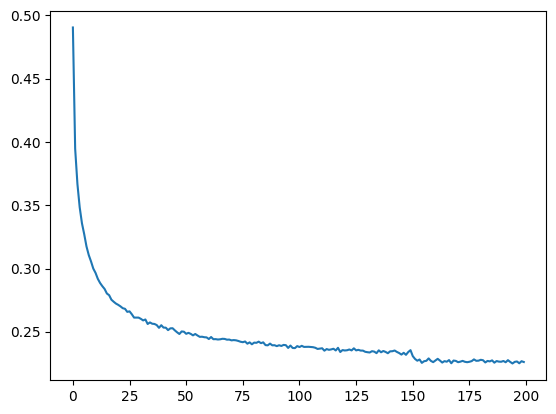

In [206]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))

In [207]:
#now, sending the layers to "eval" mode
for layer in model.layers:
    layer.training = False

In [208]:
@torch.no_grad() #decorator : disables gradient tracking
def split_loss(split):
    XXb,YYb = {
        'train': (Xtr, Ytr),
        'val': (Xval, Yval),
        'test': (Xtest, Ytest)
    }[split]

    #processing in batches and accumulating losses
    losses = []

    ##processing X and Y in batches as GPU memory isn't enough
    for i in range(0, XXb.shape[0], 1000):
        Xbatch = XXb[i:i+1000] 
        Ybatch = YYb[i:i+1000]
        #forward pass
        logits=model(Xbatch)
        loss=f.cross_entropy(logits, Ybatch)
        losses.append(loss.item())
    print(split, sum(losses)/len(losses)) #avg loss obtained in training set
        

split_loss('train')
split_loss('val')


train 1.6458440031110722
val 1.6513031754413796


In [209]:
#GENERATOR CODE:
def generate_headline():
    create_headline = []
    context_window = [0] * block_size
    while True:
        #forward pass
        logits = model(torch.tensor([context_window])) #passing a tensor input into the model
        y_pred = f.softmax(logits, dim=1)

        idx = torch.multinomial(y_pred, 1) #sample from distrubution

        #if char = '<E>', break the loop
        if num2letter_dict[idx.item()] == '<E>':
            break

        create_headline.append(num2letter_dict[idx.item()]) #converting index to character and appending it
        context_window = context_window[1:] + [idx.item()] #moving the context window

    return ''.join(create_headline)


for i in range(10):
    print(f'Headline {i+1}: ', generate_headline())


Headline 1:  Lorands News after risk backing as mutt
Headline 2:  Fland needs with mine of 5T19 down in 3,200 to May craship approval rerms?
Headline 3:  Companillion focumve count U.S. 2019 nillion a sales runclai and ristons couder ceriscrivipe
Headline 4:  Dotve for stigher expecetail: The trandencern fore, crisives to boronavirus jumpt prepton splain'
Headline 5:  Musird says U.S. crude' in Saketh fouroog unbwinrine
Headline 6:  Oil projore
Headline 7:  Weakment Marmer Remivon tariff lose cut meco-adminia, BAO the Barry'
Headline 8:  Unilers forecast action transen of trade dritain take
Headline 9:  Ekicition to leat ceefects
Headline 10:  Co about stock commited over hen $3igs of newmu:e trade India stopclue forcental over at Shoudenish isses to firms power of appest,,


SyntaxError: invalid character '←' (U+2190) (164379758.py, line 1)